# Pair Classifier — Confident Match vs. Everything Else (LightGBM, **v5**)

**Entity resolution / confident-match detection.** Over the **whole** pool of candidate record
pairs, predict **confident match** (`1`) vs **everything else** (`0` = ambiguous ∪ confident
non-match).

## What changed from v4, and why it matters

v4 trained the *same* boundary over the *same* population — but stated backwards: its class `1`
was "ambiguous ∪ non-match", so the served score had to be computed as `1 - P(class 1)`. That
single inversion propagated:

| | v3 / v4 (retired) | **v5** |
|---|---|---|
| model's class `1` | ambiguous (∪ non-match) | **confident match** |
| served `match_probability` | `1 - predict_proba[:, 1]` | `predict_proba[:, 1]` |
| serve adapter | `MatchProbabilityAdapter` (swapped columns) | `DirectMatchAdapter` (pass-through) |
| SHAP contributions | **negated**, base value included | passed through as-is |
| this notebook's `proba_test` | `P(class 1)`, read inverted everywhere | the served score, directly |

The v3/v4 **serving** code (`lightgbm_v3.py`, `MatchProbabilityAdapter`) has since been
deleted, so artifacts exported by those notebooks no longer load at all. Their training
notebooks remain next to this one as research history — v4 in particular is the baseline
the §8 metrics below are compared against.

The SHAP negation was the sharp edge: get it backwards and the reviewer sees a waterfall that
reads plausibly and is exactly wrong. v5 removes the inversion rather than guarding it.

**The decision boundary is unchanged.** v4's `P(class 1) >= 0.30` and v5's
`P(confident match) >= 0.70` are the same cut, so `EMPI_ML_AUTO_MERGE_THRESHOLD=0.70` needs no
change and the §8 metrics are directly comparable to v4's.

## Where this model sits

Pipeline **Stage 4.5**, the ML matcher. It is trained here on the **whole** candidate pool, but at
serve time the Stage-4.25 non-match gate has already dropped the confident non-matches (0.999
held-out plausible recall), so it scores gate survivors and runs as a **2-tier** classifier:
`auto_merge` (score ≥ 0.70) vs `human_review` (`EMPI_ML_REVIEW_FLOOR=0.0`, so no `no_match` tier).
`ml_feeds_clustering` is on — the `auto_merge` tier forms real merge edges, so §8.4's precision is
a production safety property, not a report card.

> **Not** the non-match gate. That is a separate model with its own store and notebook
> (`../confident_nonmatch/pair_classifier_lightgbm_nonmatch_gate_v1.ipynb`); §11 here writes only
> to the `ml_matcher` store.

## 1. Setup & configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import jellyfish

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

In [3]:
from pathlib import Path

def _find_service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / 'data').is_dir() and (d / 'src').is_dir():
            return d
    raise FileNotFoundError("could not locate empi-service/ (no ancestor has data/ + src/)")

SERVICE_ROOT = _find_service_root(Path.cwd())
DATA_DIR = SERVICE_ROOT / 'data'

GOLD_LABELS_PATH = DATA_DIR / 'gold_labels' / 'final_gold_labels_v1_2026_07_05.csv'
CLEANED_PATH = DATA_DIR / 'processed' / 'MDM_Population_cleaned_v6_2026_06_25.parquet'

print('service root :', SERVICE_ROOT)
print('gold labels  :', GOLD_LABELS_PATH, '-> exists:', GOLD_LABELS_PATH.exists())
print('cleaned data :', CLEANED_PATH, '-> exists:', CLEANED_PATH.exists())

service root : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
gold labels  : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\gold_labels\final_gold_labels_v1_2026_07_05.csv -> exists: True
cleaned data : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\processed\MDM_Population_cleaned_v6_2026_06_25.parquet -> exists: True


## 2. Data ingestion
Identical to v3/v4. `dtype=str` on PATIDs preserves the leading-zeros invariant.

In [4]:
gold = pd.read_csv(GOLD_LABELS_PATH, dtype={'PATID_A': str, 'PATID_B': str})


def _to_bool(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    return s.astype(str).str.strip().str.lower().map(
        {'true': True, '1': True, '1.0': True, 'false': False, '0': False, '0.0': False})


gold['final_gold_label'] = _to_bool(gold['final_gold_label']).fillna(False).astype(bool)
gold['ambiguous_pair'] = _to_bool(gold['ambiguous_pair']).fillna(False).astype(bool)

print('gold labels shape :', gold.shape)
print('\nfinal_gold_label x ambiguous_pair (counts):')
print(pd.crosstab(gold['final_gold_label'], gold['ambiguous_pair']))

gold labels shape : (204805, 4)

final_gold_label x ambiguous_pair (counts):
ambiguous_pair     False  True 
final_gold_label               
False             142195     73
True               34560  27977


In [5]:
ATTRIBUTE_COLS = [
    'FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean',
    'SSN_clean', 'last_4_SSN', 'Email_clean', 'ZipCD_clean_base',
    'AddressLine1_clean', 'SexAtBirthDSC_clean', 'Phones_set',
]
cleaned = pd.read_parquet(CLEANED_PATH)
keep = ['PATID'] + [c for c in ATTRIBUTE_COLS if c in cleaned.columns]
cleaned = cleaned[keep].copy()
cleaned['PATID'] = cleaned['PATID'].astype(str)
cleaned = cleaned.drop_duplicates(subset='PATID', keep='first').set_index('PATID')
print('cleaned records shape:', cleaned.shape)
print('columns available    :', list(cleaned.columns))

cleaned records shape: (163364, 11)
columns available    : ['FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean', 'SSN_clean', 'last_4_SSN', 'Email_clean', 'ZipCD_clean_base', 'AddressLine1_clean', 'SexAtBirthDSC_clean', 'Phones_set']


In [6]:
a = cleaned.add_suffix('_A').reindex(gold['PATID_A'].values).reset_index(drop=True)
b = cleaned.add_suffix('_B').reindex(gold['PATID_B'].values).reset_index(drop=True)
pairs = pd.concat([gold.reset_index(drop=True), a, b], axis=1)

n_unmatched = (~gold['PATID_A'].isin(cleaned.index) | ~gold['PATID_B'].isin(cleaned.index)).sum()
print(f'pairs with a PATID not found in cleaned data: {n_unmatched} / {len(pairs)}')
print('joined pairs shape:', pairs.shape)

pairs with a PATID not found in cleaned data: 0 / 204805
joined pairs shape: (204805, 26)


## 3. Target definition (no population filter) — the v5 change

**No filtering** — the whole candidate pool is used, exactly as in v4. The target is v4's,
**flipped**: `1` = **confident match** (`final_gold_label` AND NOT `ambiguous_pair`), `0` =
everything else (ambiguous ∪ confident non-match).

Same partition of the same rows; only the class names swap. That is what makes
`predict_proba[:, 1]` the served score directly, and it is why the §6 split below comes out
identical to v4's (stratifying on a flipped label stratifies on the same partition).

In [7]:
confident_match = pairs['final_gold_label'] & ~pairs['ambiguous_pair']
pairs['target_confident_match'] = confident_match.astype(int)

print('target distribution (1=confident match, 0=ambiguous ∪ confident non-match):')
print(pairs['target_confident_match'].value_counts())
print(f"\npositive rate (class 1 = confident match): {pairs['target_confident_match'].mean():.3f}")
print('\nbreakdown of the negative class (target=0):')
print(f"  ambiguous          (ambiguous_pair)               : {int(pairs['ambiguous_pair'].sum())}")
print(f"  confident non-match(~final_gold_label & ~ambiguous): {int((~pairs['final_gold_label'] & ~pairs['ambiguous_pair']).sum())}")

target distribution (1=confident match, 0=ambiguous ∪ confident non-match):
target_confident_match
0    170245
1     34560
Name: count, dtype: int64

positive rate (class 1 = confident match): 0.169

breakdown of the negative class (target=0):
  ambiguous          (ambiguous_pair)               : 28050
  confident non-match(~final_gold_label & ~ambiguous): 142195


## 4. Field selection
Same 8-field roster as v3/v4. Drives both the **internal** `cmp_all` comparison (used for the
aggregate-free subgroup rule + ablation) and the v3 similarity features.

In [8]:
AVAILABLE_FIELDS = {
    'first_name':  'FirstNM_clean',
    'last_name':   'LastNM_clean',
    'middle_name': 'MiddleNM_clean',
    'birth_date':  'BirthDT_clean',
    'email':       'Email_clean',
    'ssn':         'SSN_clean',
    'address1':    'AddressLine1_clean',
    'phones':      'Phones_set',
}
SET_FIELDS = {'phones'}
SELECTED_FIELDS = ['first_name', 'last_name', 'middle_name', 'birth_date',
                   'email', 'ssn', 'address1', 'phones']
assert set(SELECTED_FIELDS) <= set(AVAILABLE_FIELDS)
print('fields:', SELECTED_FIELDS)

fields: ['first_name', 'last_name', 'middle_name', 'birth_date', 'email', 'ssn', 'address1', 'phones']


## 5. Feature engineering

**Identical to v3/v4** — the 12 features are unchanged, which is deliberate: the production
builder is `FeatureBuilderV5` in `src/models/ml_matcher/lightgbm_v5.py`, and the Stage-4.25
non-match gate imports that same class. One implementation to keep correct, and v4-vs-v5 stays
a label-only comparison.

All features are continuous **except** `cmp_street_num`, `sound_first`, `sound_last` (3-level
categoricals). Missing on either side → `NaN`, handled natively by LightGBM.

| Feature | Type | Definition |
|---|---|---|
| `sim_jw_first` / `sim_jw_last` / `sim_jw_middle` | num | Jaro-Winkler on the name |
| `sound_first` / `sound_last` | cat | Metaphone code same / different / missing |
| `sim_dob` | num | normalized Levenshtein on the `YYYYMMDD` digit string |
| `ssn_digit_frac` | num | fraction of position-wise matching SSN digits |
| `sim_lev_email` / `sim_lev_address1` | num | normalized Levenshtein |
| `cmp_street_num` | cat | first numeric token of the address, exact |
| `addr_token_jaccard` | num | token Jaccard on address line 1 |
| `sim_phones` | num | best Jaro-Winkler across the two phone sets |

In [9]:
import ast, re

MISSING, SAME, DIFFERENT = 'missing', 'same', 'different'
COMPARE_LEVELS = [MISSING, SAME, DIFFERENT]
_num_re = re.compile(r'\d+')
_NA_TOKENS = {'nan', 'none', '<na>', 'nat', 'null'}


def _norm(x):
    """Value -> lowercased stripped str, or None for any missing kind
    (None / np.nan / pd.NA / NaT). pd.NA is NOT an np.isscalar, so we test via pd.isna()."""
    if isinstance(x, str):
        s = x.strip().lower()
        return s if s and s not in _NA_TOKENS else None
    if x is None:
        return None
    try:
        if pd.isna(x):
            return None
    except (TypeError, ValueError):
        pass
    s = str(x).strip().lower()
    return s if s and s not in _NA_TOKENS else None


def _norm_series(s: pd.Series) -> pd.Series:
    return s.astype(object).map(_norm)


def _parse_set(value) -> set:
    """Set-valued cell (phones) -> set of strings. Handles native array/list and legacy string."""
    if isinstance(value, (set, frozenset, list, tuple, np.ndarray)):
        return {str(p).strip() for p in value if str(p).strip()}
    if pd.isna(value) or not isinstance(value, str):
        return set()
    v = value.strip()
    if v in ('', 'nan', 'None', 'set()', '{}', '[]'):
        return set()
    try:
        parsed = ast.literal_eval(v)
        if isinstance(parsed, (set, list, tuple)):
            return {str(p).strip() for p in parsed if str(p).strip()}
    except (ValueError, SyntaxError, TypeError):
        pass
    cleaned = v.strip('{}[]').replace("'", '').replace('"', '')
    return {p.strip() for p in cleaned.split(',') if p.strip()}


def _jw(x, y):
    if not (isinstance(x, str) and isinstance(y, str)):
        return np.nan
    return jellyfish.jaro_winkler_similarity(x, y)


def _lev_sim(x, y):
    if not (isinstance(x, str) and isinstance(y, str)):
        return np.nan
    m = max(len(x), len(y))
    return 1.0 - jellyfish.levenshtein_distance(x, y) / m if m else np.nan

### 5.1 Internal per-field comparison (`cmp_all`)
Computed for all eight fields but **not** used as model features (per v3, the aggregates are
dropped). It feeds the section-9 subgroup rule and the ablation baseline only.

In [10]:
def compare_field(df: pd.DataFrame, name: str, col: str) -> pd.Categorical:
    if name in SET_FIELDS:
        a = df[f'{col}_A'].apply(_parse_set)
        b = df[f'{col}_B'].apply(_parse_set)
        missing = (a.map(len) == 0) | (b.map(len) == 0)
        same = pd.Series([bool(x & y) for x, y in zip(a, b)], index=df.index) & ~missing
    else:
        a = _norm_series(df[f'{col}_A'])
        b = _norm_series(df[f'{col}_B'])
        missing = a.isna() | b.isna()
        same = (a == b) & ~missing
    out = np.where(missing, MISSING, np.where(same, SAME, DIFFERENT))
    return pd.Categorical(out, categories=COMPARE_LEVELS)


cmp_all = pd.DataFrame(index=pairs.index)
for name in SELECTED_FIELDS:
    cmp_all[f'cmp_{name}'] = compare_field(pairs, name, AVAILABLE_FIELDS[name])
print('internal cmp_all columns:', list(cmp_all.columns))

internal cmp_all columns: ['cmp_first_name', 'cmp_last_name', 'cmp_middle_name', 'cmp_birth_date', 'cmp_email', 'cmp_ssn', 'cmp_address1', 'cmp_phones']


### 5.2 Model features

In [11]:
feat = pd.DataFrame(index=pairs.index)
cat_features, num_features = [], []


def sim_column(col, fn):
    a = _norm_series(pairs[f'{col}_A'])
    b = _norm_series(pairs[f'{col}_B'])
    return pd.Series([fn(x, y) for x, y in zip(a, b)], index=pairs.index, dtype='float')


# --- Names: Jaro-Winkler ---
for name in ['first_name', 'last_name', 'middle_name']:
    feat[f'sim_jw_{name.split("_")[0]}'] = sim_column(AVAILABLE_FIELDS[name], _jw)
num_features += ['sim_jw_first', 'sim_jw_last', 'sim_jw_middle']

# --- Email / address: normalized Levenshtein only ---
feat['sim_lev_email'] = sim_column('Email_clean', _lev_sim)
feat['sim_lev_address1'] = sim_column('AddressLine1_clean', _lev_sim)
num_features += ['sim_lev_email', 'sim_lev_address1']

In [12]:
# --- Names: phonetic (Metaphone) sound-alike match ---
def _metaphone(x):
    s = _norm(x)
    if not s:
        return None
    return jellyfish.metaphone(s) or None


def sound_cmp(col):
    a = pairs[f'{col}_A'].map(_metaphone)
    b = pairs[f'{col}_B'].map(_metaphone)
    missing = a.isna() | b.isna()
    same = (a == b) & ~missing
    return pd.Categorical(np.where(missing, MISSING, np.where(same, SAME, DIFFERENT)), categories=COMPARE_LEVELS)


feat['sound_first'] = sound_cmp('FirstNM_clean')
feat['sound_last'] = sound_cmp('LastNM_clean')
cat_features += ['sound_first', 'sound_last']

In [13]:
# --- Address: street number (first numeric token), matched exactly; + token Jaccard ---
def _street_num(x):
    s = _norm(x)
    if not s:
        return None
    m = _num_re.search(s)
    return m.group() if m else None


sn_a = pairs['AddressLine1_clean_A'].map(_street_num)
sn_b = pairs['AddressLine1_clean_B'].map(_street_num)
sn_missing = sn_a.isna() | sn_b.isna()
sn_same = (sn_a == sn_b) & ~sn_missing
feat['cmp_street_num'] = pd.Categorical(
    np.where(sn_missing, MISSING, np.where(sn_same, SAME, DIFFERENT)), categories=COMPARE_LEVELS)
cat_features.append('cmp_street_num')


def _tok_jaccard(x, y):
    x, y = _norm(x), _norm(y)
    if not x or not y:
        return np.nan
    sx, sy = set(x.split()), set(y.split())
    return len(sx & sy) / len(sx | sy) if sx and sy else np.nan


feat['addr_token_jaccard'] = pd.Series(
    [_tok_jaccard(x, y) for x, y in zip(pairs['AddressLine1_clean_A'], pairs['AddressLine1_clean_B'])],
    index=pairs.index, dtype='float')
num_features.append('addr_token_jaccard')

In [14]:
# --- SSN: fraction of position-wise matching digits (typo-tolerant). ---
def _ssn_frac(x, y):
    x, y = _norm(x), _norm(y)
    if not x or not y:
        return np.nan
    n = min(len(x), len(y))
    if n == 0:
        return np.nan
    return sum(1 for i in range(n) if x[i] == y[i]) / max(len(x), len(y))


feat['ssn_digit_frac'] = pd.Series(
    [_ssn_frac(x, y) for x, y in zip(pairs['SSN_clean_A'], pairs['SSN_clean_B'])],
    index=pairs.index, dtype='float')
num_features.append('ssn_digit_frac')

In [15]:
# --- DOB: typo-tolerant similarity on the YYYYMMDD digit string (normalized Levenshtein). ---
dob_a = pd.to_datetime(pairs['BirthDT_clean_A'], errors='coerce')
dob_b = pd.to_datetime(pairs['BirthDT_clean_B'], errors='coerce')
sa = dob_a.dt.strftime('%Y%m%d')   # NaT -> NaN
sb = dob_b.dt.strftime('%Y%m%d')
feat['sim_dob'] = pd.Series([_lev_sim(x, y) for x, y in zip(sa, sb)], index=pairs.index, dtype='float')
num_features.append('sim_dob')

In [16]:
# --- Phones: best (max) Jaro-Winkler across all cross pairs of the two phone sets. ---
#     = smallest JW distance. Exact shared number -> 1.0; a one-digit typo still scores high.
def _phones_best_jw(av, bv):
    A, B = _parse_set(av), _parse_set(bv)
    if not A or not B:
        return np.nan
    return max(jellyfish.jaro_winkler_similarity(x, y) for x in A for y in B)


feat['sim_phones'] = pd.Series(
    [_phones_best_jw(av, bv) for av, bv in zip(pairs['Phones_set_A'], pairs['Phones_set_B'])],
    index=pairs.index, dtype='float')
num_features.append('sim_phones')

In [17]:
# Finalize: categorical dtype for tree-native categoricals; assemble feature list.
for c in cat_features:
    feat[c] = feat[c].astype('category')

FEATURE_COLS = cat_features + num_features
print(f'{len(cat_features)} categorical + {len(num_features)} numeric = {len(FEATURE_COLS)} features')
print('\ncategorical:', cat_features)
print('numeric    :', num_features)
feat[FEATURE_COLS].head()

3 categorical + 9 numeric = 12 features

categorical: ['sound_first', 'sound_last', 'cmp_street_num']
numeric    : ['sim_jw_first', 'sim_jw_last', 'sim_jw_middle', 'sim_lev_email', 'sim_lev_address1', 'addr_token_jaccard', 'ssn_digit_frac', 'sim_dob', 'sim_phones']


,sound_first,sound_last,cmp_street_num,sim_jw_first,sim_jw_last,sim_jw_middle,sim_lev_email,sim_lev_address1,addr_token_jaccard,ssn_digit_frac,sim_dob,sim_phones
0,same,same,same,1.000000,1.0,NaN,NaN,1.000000,1.000000,NaN,1.0,1.000000
1,same,same,same,1.000000,1.0,NaN,0.464286,1.000000,1.000000,NaN,1.0,1.000000
2,same,same,same,0.971429,1.0,NaN,NaN,1.000000,1.000000,NaN,1.0,1.000000
3,same,same,different,1.000000,1.0,NaN,1.000000,0.285714,0.166667,1.0,1.0,1.000000
4,same,same,different,1.000000,1.0,NaN,NaN,0.476190,0.333333,NaN,1.0,0.622222


### 5.3 Feature ↔ target signal check
Read in the v5 direction: the positive class is now the confident match, so a discriminative
feature has a **higher** mean in class 1.

In [18]:
y_full = pairs['target_confident_match']
rows = []
for c in num_features:
    rows.append({'feature': c,
                 'mean_class1_match': feat.loc[y_full == 1, c].mean(),
                 'mean_class0_other': feat.loc[y_full == 0, c].mean(),
                 'pct_missing': feat[c].isna().mean()})
print('Numeric features — mean by class (1=confident match, 0=ambiguous ∪ non-match):')
display(pd.DataFrame(rows).round(3))

for c in cat_features:
    ct = pairs.groupby(feat[c].astype('object'), observed=True)['target_confident_match'].mean().round(3)
    print(f'{c:16s} P(confident match|outcome): ' + '  '.join(f'{k}={v}' for k, v in ct.items()))

Numeric features — mean by class (1=confident match, 0=ambiguous ∪ non-match):


,feature,mean_class1_match,mean_class0_other,pct_missing
0,sim_jw_first,0.989,0.536,0.000
1,sim_jw_last,0.975,0.556,0.000
2,sim_jw_middle,0.916,0.205,0.972
3,sim_lev_email,0.872,0.612,0.948
4,sim_lev_address1,0.638,0.639,0.041
5,addr_token_jaccard,0.519,0.535,0.041
6,ssn_digit_frac,0.990,0.201,0.770
7,sim_dob,1.000,0.556,0.000
8,sim_phones,0.865,0.928,0.042


sound_first      P(confident match|outcome): different=0.01  missing=0.0  same=0.506
sound_last       P(confident match|outcome): different=0.025  missing=1.0  same=0.446
cmp_street_num   P(confident match|outcome): different=0.162  missing=0.152  same=0.175


## 6. Train / validation / test split — the SHARED holdout

The test fold is **not drawn here**. `src.evaluation.holdout.holdout_mask` defines
it, and the same function is called by the other training notebook and by both
evaluation CLIs — so there is exactly one definition of the split and the two
served models are held out on exactly the same pairs.

**How it is defined.** A pair is held out iff
`sha256(PATID_A|PATID_B|salt)`, read as a fraction in [0, 1), is below
`HOLDOUT_FRACTION` (0.20). Membership therefore depends only on the pair's own
identity, which buys three things:

* **order-invariance** — `train_test_split` is positional, so re-saving the gold
  CSV in a different row order would silently change which pairs are held out and
  invalidate every already-trained model, with nothing raised;
* **stability under growth** — appending new gold labels re-partitions nothing;
* **stratification for free** — the hash is independent of the label, so it takes
  ~20% of every class without being told the classes exist (measured: non-match
  19.98%, ambiguous 20.18%, match 19.71%).

**Why not a per-notebook split, as before?** Each notebook used to call
`train_test_split` itself and `holdout.py` reconstructed those splits separately.
The folds were *different* 20%s, so "pairs neither model saw" was their
intersection — ~8k of 204,805 — and the reconstruction drifted silently when a
notebook changed its stratification target, quietly contaminating every
"leakage-safe" number. One shared function makes the safe set the full ~41k
(~5x the positive labels) and leaves nothing to drift.

Train/val is still split here (75/25 of the remaining 80% → 60/20 overall);
only the *test* fold has to be shared.

In [19]:
import sys
if str(SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVICE_ROOT))
from src.evaluation.holdout import holdout_mask, holdout_spec   # noqa: E402

X = feat[FEATURE_COLS]
y = pairs['target_confident_match'].astype(int)

# The shared holdout — same function the other notebook and the eval CLIs call.
HOLDOUT_SPEC = holdout_spec()          # recorded in the model meta (section 11)
is_test = holdout_mask(pairs)

idx_test = np.flatnonzero(is_test)
idx_trainval = np.flatnonzero(~is_test)
assert len(idx_test) > 0, 'empty holdout — check PATID formatting in the gold file'

idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y.iloc[idx_trainval])

X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val,   y_val   = X.iloc[idx_val],   y.iloc[idx_val]
X_test,  y_test  = X.iloc[idx_test],  y.iloc[idx_test]

print(f'holdout spec: {HOLDOUT_SPEC}')
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'{name:5s}: n={len(yy):6d}  pos={yy.sum():6d}  pos_rate={yy.mean():.3f}')

train: n=122883  confident_match= 20736  rate=0.169
val  : n= 40961  confident_match=  6912  rate=0.169
test : n= 40961  confident_match=  6912  rate=0.169


## 7. Model training
Same LightGBM configuration as v3/v4 — only the target's orientation differs.
`class_weight='balanced'` handles the imbalance (class 1 is now the **minority**: the confident
matches are outnumbered by ambiguous ∪ non-match).

In [20]:
params = dict(
    objective='binary', n_estimators=1000, learning_rate=0.05, num_leaves=15,
    min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_lambda=1.0, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

model = lgb.LGBMClassifier(**params)
model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)],
)
print('best iteration:', model.best_iteration_)
print('best val AUC  :', round(model.best_score_['valid_0']['auc'], 4))

best iteration: 492
best val AUC  : 0.9984


## 8. Model evaluation (full held-out test set)

Positive class = **confident match**, and `proba_test` is the **served score** — no `1 - p`
anywhere below. The threshold is the pipeline's own `EMPI_ML_AUTO_MERGE_THRESHOLD = 0.70`, which
is the same cut as v4's `P(class 1) >= 0.30`.

The costly error is a **false positive**: an auto-merge that shouldn't have happened is a wrong
merge in production (`ml_feeds_clustering` is on). A false negative just routes the pair to a
human. So read **precision** first here.

In [38]:
AUTO_MERGE_THRESHOLD = 0.70                       # == EMPI_ML_AUTO_MERGE_THRESHOLD
proba_test = model.predict_proba(X_test)[:, 1]    # P(confident match) — the served score, as-is
pred_test = (proba_test >= AUTO_MERGE_THRESHOLD).astype(int)

print('Classification report (full test):\n')
print(classification_report(y_test, pred_test, target_names=['ambiguous ∪ non-match (0)', 'confident match (1)'], digits=3))
print(f'ROC AUC : {roc_auc_score(y_test, proba_test):.4f}')
print(f'PR  AUC : {average_precision_score(y_test, proba_test):.4f}')

Classification report (full test):

                           precision    recall  f1-score   support

ambiguous ∪ non-match (0)      0.996     0.980     0.988     34049
      confident match (1)      0.908     0.979     0.942      6912

                 accuracy                          0.980     40961
                macro avg      0.952     0.979     0.965     40961
             weighted avg      0.981     0.980     0.980     40961

ROC AUC : 0.9982
PR  AUC : 0.9917


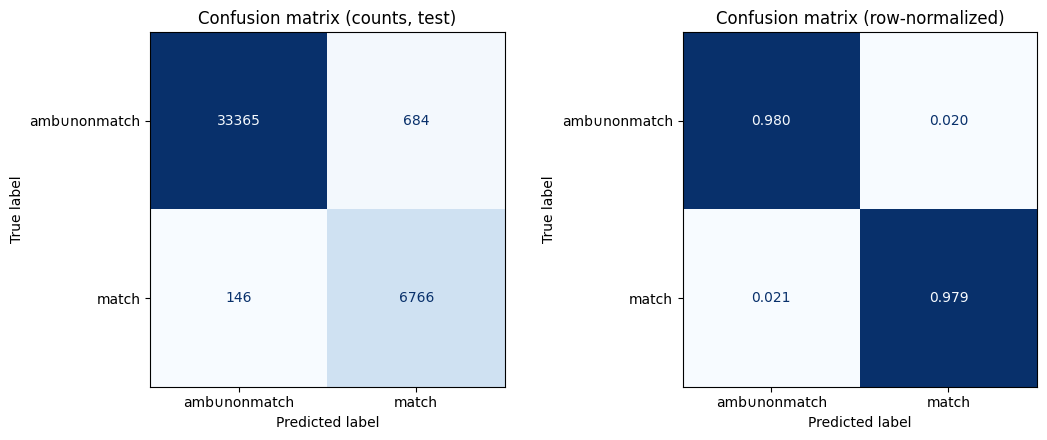

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['amb∪nonmatch', 'match']
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test), display_labels=labels).plot(ax=ax[0], colorbar=False, cmap='Blues')
ax[0].set_title('Confusion matrix (counts, test)')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test, normalize='true'), display_labels=labels).plot(ax=ax[1], colorbar=False, cmap='Blues', values_format='.3f')
ax[1].set_title('Confusion matrix (row-normalized)')
plt.tight_layout(); plt.show()

### 8.2 ROC / PR curves
Both are now oriented on the confident-match class directly, so the PR curve is the one that
matters: it is precision/recall of the `auto_merge` tier as the threshold sweeps.

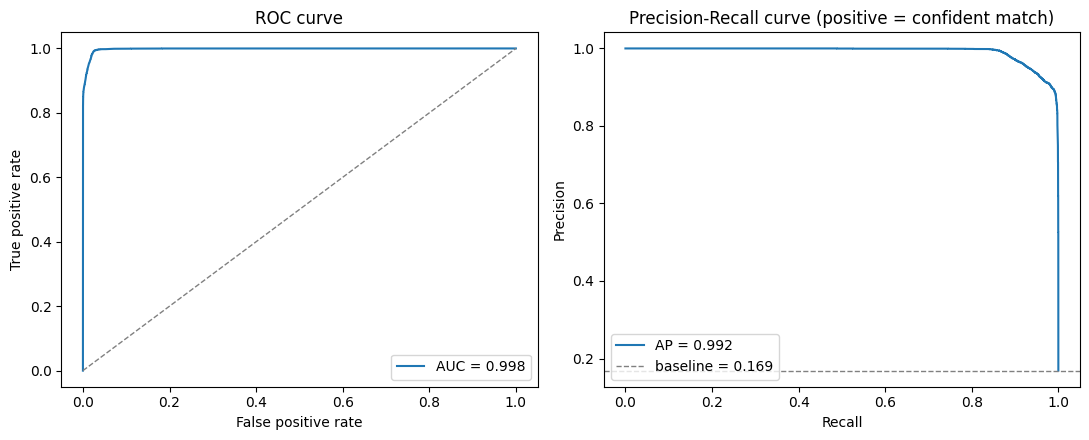

In [23]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, proba_test):.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curve'); ax[0].legend(loc='lower right')
ax[1].plot(rec, prec, label=f'AP = {average_precision_score(y_test, proba_test):.3f}')
ax[1].axhline(y_test.mean(), ls='--', color='grey', linewidth=1, label=f'baseline = {y_test.mean():.3f}')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall curve (positive = confident match)'); ax[1].legend(loc='lower left')
plt.tight_layout(); plt.show()

### 8.3 `auto_merge` operating points
Scan the threshold to size the tier: at each cut, what fraction of the pool auto-merges, and at
what precision. Since the merges are real, pick the operating point from the **precision** column
against the wrong-merge rate you can tolerate — then set `EMPI_ML_AUTO_MERGE_THRESHOLD` to it.
Everything below the cut becomes `human_review`, not a drop, so recall here is review workload,
not lost pairs.

In [24]:
rows = []
P = int((y_test == 1).sum())
for thr in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
    merged = proba_test >= thr
    tp = int((merged & (y_test.values == 1)).sum())
    fp = int((merged & (y_test.values == 0)).sum())
    rows.append({
        'threshold': thr,
        'auto_merged': int(merged.sum()),
        'pct_of_pool': round(merged.mean(), 4),
        'precision': round(tp / (tp + fp), 4) if (tp + fp) else float('nan'),
        'recall': round(tp / P, 4) if P else float('nan'),
        'wrong_merges (fp)': fp,
    })
print('auto_merge tier by threshold (held-out test):')
display(pd.DataFrame(rows))

auto_merge tier by threshold (held-out test):


,threshold,auto_merged,pct_of_pool,precision,recall,wrong_merges (fp)
0,0.50,7657,0.1869,0.8933,0.9896,817
1,0.60,7594,0.1854,0.8974,0.9860,779
2,0.70,7450,0.1819,0.9082,0.9789,684
3,0.80,7079,0.1728,0.9316,0.9541,484
4,0.90,6211,0.1516,0.9834,0.8837,103
5,0.95,5982,0.1460,0.9952,0.8613,29


### 8.4 The served `auto_merge` tier — deploy-gate metrics
The precision/recall the registry's deploy gate reads from the `.meta.json` sidecar (§11), at the
threshold the pipeline actually serves. In v4 this section had to reconstruct the score as
`1 - proba_test`; in v5 the tier is just `proba_test >= 0.70`, which is why this is now three
lines that mirror the classification report above rather than a re-derivation.

In [25]:
pred_auto = (proba_test >= AUTO_MERGE_THRESHOLD).astype(int)
y_match = y_test.values

tp = int(((pred_auto == 1) & (y_match == 1)).sum())
fp = int(((pred_auto == 1) & (y_match == 0)).sum())
fn = int(((pred_auto == 0) & (y_match == 1)).sum())
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
print(f'auto_merge (confident-match) tier @ score>={AUTO_MERGE_THRESHOLD}:')
print(f'  precision={precision:.4f}  recall={recall:.4f}  (tp={tp} fp={fp} fn={fn})')

auto_merge (confident-match) tier @ score>=0.7:
  precision=0.9082  recall=0.9789  (tp=6766 fp=684 fn=146)


### 8.5 Serving-population evaluation (gate survivors only)
The model trains on the whole pool but **serves** on what the Stage-4.25 gate passes: the
plausible pairs (`final_gold_label | ambiguous_pair`). Restricting the held-out set to those
approximates the population it will actually see, and collapses class `0` back to just
*ambiguous* — so this is also the v3-comparable confusion matrix.

Expect precision here to be *lower* than §8.4's: the easy negatives (confident non-matches) are
gone, and what remains is the hard boundary. This, not §8.4, is the number that predicts
production behavior.

test set: 12453 plausible kept, 28508 confident non-matches excluded (of 40961)
confident-match rate within plausible test subset: 0.555

Classification report (test, confident non-matches excluded), threshold=0.7:

                     precision    recall  f1-score   support

      ambiguous (0)      0.973     0.933     0.952      5541
confident match (1)      0.948     0.979     0.963      6912

           accuracy                          0.958     12453
          macro avg      0.960     0.956     0.958     12453
       weighted avg      0.959     0.958     0.958     12453

ROC AUC : 0.9932
PR  AUC : 0.9947

auto_merge tier on the serving population: precision=0.9480 recall=0.9789 (tp=6766 fp=371 fn=146)


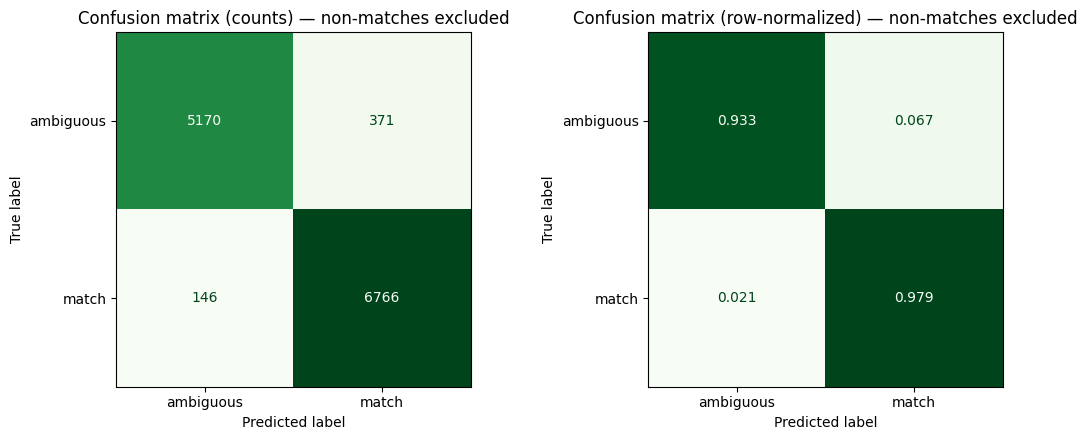

In [26]:
# Plausible = match ∪ ambiguous (i.e. NOT a confident non-match) — the gate's survivors.
plausible_all = (pairs['final_gold_label'] | pairs['ambiguous_pair']).values
mask_test_plausible = plausible_all[idx_test]

y_test_p = y_test.values[mask_test_plausible]     # 1 == confident match, 0 == ambiguous
pred_test_p = pred_test[mask_test_plausible]
proba_test_p = proba_test[mask_test_plausible]

n_excluded = int((~mask_test_plausible).sum())
print(f'test set: {mask_test_plausible.sum()} plausible kept, {n_excluded} confident non-matches excluded '
      f'(of {len(y_test)})')
print(f'confident-match rate within plausible test subset: {y_test_p.mean():.3f}\n')

print(f'Classification report (test, confident non-matches excluded), threshold={AUTO_MERGE_THRESHOLD}:\n')
print(classification_report(y_test_p, pred_test_p, target_names=['ambiguous (0)', 'confident match (1)'], digits=3))
print(f'ROC AUC : {roc_auc_score(y_test_p, proba_test_p):.4f}')
print(f'PR  AUC : {average_precision_score(y_test_p, proba_test_p):.4f}')

tp_p = int(((pred_test_p == 1) & (y_test_p == 1)).sum())
fp_p = int(((pred_test_p == 1) & (y_test_p == 0)).sum())
fn_p = int(((pred_test_p == 0) & (y_test_p == 1)).sum())
prec_p = tp_p / (tp_p + fp_p) if (tp_p + fp_p) else 0.0
rec_p = tp_p / (tp_p + fn_p) if (tp_p + fn_p) else 0.0
print(f'\nauto_merge tier on the serving population: precision={prec_p:.4f} recall={rec_p:.4f} '
      f'(tp={tp_p} fp={fp_p} fn={fn_p})')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['ambiguous', 'match']
ConfusionMatrixDisplay(confusion_matrix(y_test_p, pred_test_p), display_labels=labels).plot(ax=ax[0], colorbar=False, cmap='Greens')
ax[0].set_title('Confusion matrix (counts) — non-matches excluded')
ConfusionMatrixDisplay(confusion_matrix(y_test_p, pred_test_p, normalize='true'), display_labels=labels).plot(ax=ax[1], colorbar=False, cmap='Greens', values_format='.3f')
ax[1].set_title('Confusion matrix (row-normalized) — non-matches excluded')
plt.tight_layout(); plt.show()

### 8.6 Feature importance

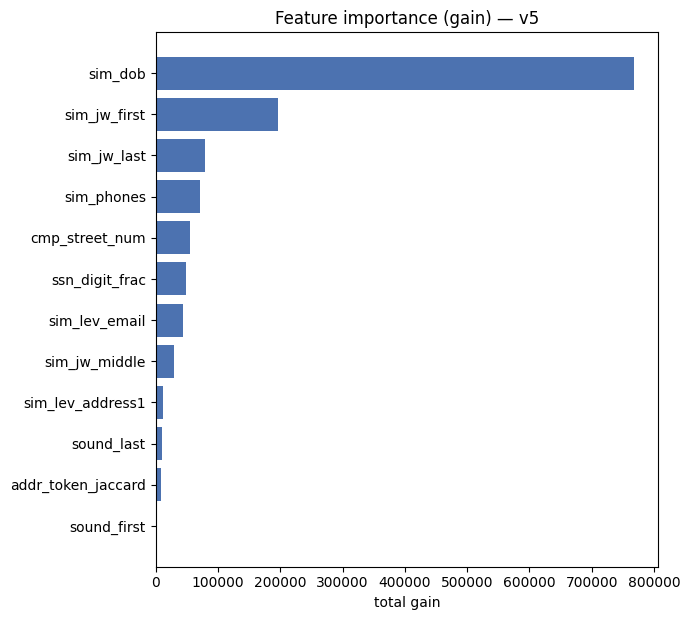

,feature,gain,split
10,sim_dob,768385.655361,281
3,sim_jw_first,196253.564958,1246
4,sim_jw_last,79654.094266,1290
11,sim_phones,71626.335528,885
2,cmp_street_num,54754.877805,205
9,ssn_digit_frac,49093.446994,471
6,sim_lev_email,44569.646005,510
5,sim_jw_middle,29805.440442,327
7,sim_lev_address1,11881.998209,977
1,sound_last,10796.249092,145


In [27]:
imp = pd.DataFrame({'feature': model.feature_name_,
                    'gain': model.booster_.feature_importance(importance_type='gain'),
                    'split': model.booster_.feature_importance(importance_type='split')}).sort_values('gain', ascending=False)
fig, ax = plt.subplots(figsize=(7, 0.4 * len(imp) + 1.5))
ax.barh(imp['feature'][::-1], imp['gain'][::-1], color='#4C72B0')
ax.set(title='Feature importance (gain) — v5', xlabel='total gain')
plt.tight_layout(); plt.show()
imp

## 9. Deterministic-rule subgroup — dual evaluation

Same **label-independent feature rule** as v3/v4 (no leakage): pairs that agree only on
first + last + DOB with everything else missing/disagreeing.

> `cmp_first_name == cmp_last_name == cmp_birth_date == same` **and** every other field `!= same`.

This is the subgroup the deterministic rules leave in `human_review`, so it is where the ML
matcher earns its keep. Reported as the confident-match rate within the subgroup, then model
metrics on the full test set, the residual, and the subgroup alone.

In [28]:
AGREE_COLS = ['cmp_first_name', 'cmp_last_name', 'cmp_birth_date']
OTHER_COLS = [c for c in cmp_all.columns if c not in AGREE_COLS]

def subgroup_mask(index_like):
    sub = cmp_all.loc[index_like]
    three_agree = (sub[AGREE_COLS] == SAME).all(axis=1)
    rest_not_same = (sub[OTHER_COLS] != SAME).all(axis=1)   # different OR missing
    return (three_agree & rest_not_same).values

# Whole population.
mask_all = subgroup_mask(pairs.index)
n_sub = int(mask_all.sum())
rate_sub = pairs.loc[mask_all, 'target_confident_match'].mean() if n_sub else float('nan')
print(f'subgroup size (full population): {n_sub} / {len(pairs)}  ({n_sub/len(pairs):.1%})')
print(f'  confident-match rate within subgroup: {rate_sub:.3f}   (overall: {pairs["target_confident_match"].mean():.3f})')

subgroup size (full population): 24373 / 204805  (11.9%)
  confident-match rate within subgroup: 0.148   (overall: 0.169)


In [29]:
# Test-set split into subgroup vs residual.
test_index = pairs.index[idx_test]
mask_test_sub = subgroup_mask(test_index)
resid = ~mask_test_sub
print(f'test set: {mask_test_sub.sum()} subgroup, {resid.sum()} residual (of {len(y_test)})\n')


def report(mask, title):
    yy, pp, sc = y_test.values[mask], pred_test[mask], proba_test[mask]
    if len(yy) == 0 or len(np.unique(yy)) < 2:
        print(f'--- {title} (n={len(yy)}): too few / single-class, skipping AUC ---')
        if len(yy):
            print(f'    accuracy={ (yy==pp).mean():.3f}  match_rate={yy.mean():.3f}')
        return
    print(f'--- {title} (n={len(yy)}, match_rate={yy.mean():.3f}) ---')
    print(classification_report(yy, pp, target_names=['amb∪nonmatch', 'match'], digits=3, zero_division=0))
    print(f'    ROC AUC={roc_auc_score(yy, sc):.4f}   PR AUC={average_precision_score(yy, sc):.4f}\n')


report(np.ones(len(y_test), bool), 'FULL test')
report(resid, 'RESIDUAL test (subgroup removed)')
report(mask_test_sub, 'SUBGROUP only')

test set: 4813 subgroup, 36148 residual (of 40961)

--- FULL test (n=40961, match_rate=0.169) ---
              precision    recall  f1-score   support

amb∪nonmatch      0.996     0.980     0.988     34049
       match      0.908     0.979     0.942      6912

    accuracy                          0.980     40961
   macro avg      0.952     0.979     0.965     40961
weighted avg      0.981     0.980     0.980     40961

    ROC AUC=0.9982   PR AUC=0.9917

--- RESIDUAL test (subgroup removed) (n=36148, match_rate=0.171) ---
              precision    recall  f1-score   support

amb∪nonmatch      0.996     0.977     0.986     29972
       match      0.899     0.979     0.937      6176

    accuracy                          0.978     36148
   macro avg      0.947     0.978     0.962     36148
weighted avg      0.979     0.978     0.978     36148

    ROC AUC=0.9980   PR AUC=0.9907

--- SUBGROUP only (n=4813, match_rate=0.153) ---
              precision    recall  f1-score   support

amb

## 10. v1-vs-v3 feature ablation
Retrain the same config on only the eight v1 `cmp_<field>` categoricals (from `cmp_all`), same
split and target, and compare threshold-free metrics. The gap is the lift from v3's similarity
features on the **v5** target.

In [30]:
v1_cols = [f'cmp_{n}' for n in SELECTED_FIELDS]
Xv1 = cmp_all[v1_cols]
Xv1_train, Xv1_val, Xv1_test = Xv1.iloc[idx_train], Xv1.iloc[idx_val], Xv1.iloc[idx_test]

m_v1 = lgb.LGBMClassifier(**params)
m_v1.fit(Xv1_train, y_train, eval_set=[(Xv1_val, y_val)], eval_metric='auc',
         categorical_feature=v1_cols,
         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)])
proba_v1 = m_v1.predict_proba(Xv1_test)[:, 1]

comparison = pd.DataFrame({
    'model': ['v1 (8 categoricals)', 'v3-features'],
    'n_features': [len(v1_cols), len(FEATURE_COLS)],
    'ROC_AUC': [roc_auc_score(y_test, proba_v1), roc_auc_score(y_test, proba_test)],
    'PR_AUC': [average_precision_score(y_test, proba_v1), average_precision_score(y_test, proba_test)],
}).round(4)
print('Held-out test comparison (same split, same config, v5 target):')
comparison

Held-out test comparison (same split, same config, v5 target):


,model,n_features,ROC_AUC,PR_AUC
0,v1 (8 categoricals),8,0.9874,0.9438
1,v3-features,12,0.9982,0.9917


## 11. Export the fitted model into the pipeline (Stage 4.5, serve-only)

Writes `ml_model_<ts>.pkl` + a deploy-gate-shaped `.meta.json` into `settings.ml_model_dir`, then
repoints `active.json`. The artifact pickles a
`src.models.ml_matcher.lightgbm_v5.DirectMatchAdapter` wrapping the fitted `LGBMClassifier` — a
pass-through wrapper, because `predict_proba[:, 1]` is already `P(confident match)`.

The artifact is named `ml_model_confident_match_v5_<ts>.pkl`. The registry discovers models by
the `ml_model_*.pkl` glob, so the descriptive middle is free-form — it exists to make the store
self-documenting about which generation an artifact belongs to.

The deploy gate compares this model's `test_metrics.metrics_auto_merge` precision/recall against
the current active model's. Those are computed the same way across v3/v4/v5 (§8.4), so the
comparison stays meaningful across the label flip.

### 11.0 Clear out pre-v5 artifacts
Moves every existing `ml_model_*.pkl` (+ sidecar + `active.json`) into a `legacy_pre_v5/`
subdirectory, out of the registry's glob. Set `ARCHIVE_LEGACY = False` to skip.
Idempotent — running it twice is a no-op.

Pre-v5 artifacts pickle an adapter class that **no longer exists**, so they already fail loudly
(`ModuleNotFoundError`) rather than being served with inverted semantics. This step is therefore
housekeeping, not a safety control: it keeps the store to one generation so nobody trips over
that error mid-pipeline-run.

Side effect worth knowing: the store ends up empty, so the promotion below counts as a *first*
promotion and the deploy gate auto-passes instead of comparing against the previous model.

In [31]:
import shutil, sys

if str(SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVICE_ROOT))
from src.config import settings                    # noqa: E402
from src.models.ml_matcher import registry         # noqa: E402

ARCHIVE_LEGACY = True

legacy_dir = settings.ml_model_dir / 'legacy_pre_v5'
existing = sorted(settings.ml_model_dir.glob('ml_model_*.pkl'))
print(f'artifacts currently visible to the registry: {len(existing)}')
for p in existing:
    print('  ', p.name)

if ARCHIVE_LEGACY and existing:
    legacy_dir.mkdir(parents=True, exist_ok=True)
    for p in existing:
        for f in [p, registry.meta_path_for(p)]:
            if f.exists():
                shutil.move(str(f), str(legacy_dir / f.name))
    pointer = settings.ml_model_dir / registry.ACTIVE_POINTER
    if pointer.exists():
        shutil.move(str(pointer), str(legacy_dir / pointer.name))
    print(f'\nmoved {len(existing)} artifact(s) + active.json -> {legacy_dir}')
    print('store is now empty -> the promotion below is a first promotion (deploy gate auto-passes)')
elif not existing:
    print('\nnothing to archive — store is empty')
else:
    print('\nARCHIVE_LEGACY=False — leaving the store as-is')

artifacts currently visible to the registry: 0

nothing to archive — store is empty


### 11.1 Save + promote

In [32]:
import json, datetime, joblib

from src.models.ml_matcher.lightgbm_v5 import DirectMatchAdapter, FEATURE_COLS as SERVED_FEATURE_COLS  # noqa: E402

# The served feature roster must match what this notebook fit on, in order —
# LightGBM matches features positionally, so a mismatch scores silently wrong.
assert list(FEATURE_COLS) == list(SERVED_FEATURE_COLS), (
    f'notebook features {FEATURE_COLS} != FeatureBuilderV5 features {SERVED_FEATURE_COLS}'
)

ts = datetime.datetime.now(datetime.timezone.utc).strftime('%Y%m%dT%H%M%SZ')
settings.ml_model_dir.mkdir(parents=True, exist_ok=True)
artifact = settings.ml_model_dir / f'ml_model_confident_match_v5_{ts}.pkl'
joblib.dump(DirectMatchAdapter(model), artifact)

meta = {
    'model_name': 'ml_matcher',
    # How 'held out' was defined when this model was fit.
    # `verify_model_provenance` compares it against the current spec, so a
    # model fit under a different split is reported, not silently trusted.
    'holdout_spec': HOLDOUT_SPEC,
    'model_file': artifact.name,
    'model_version': 'lightgbm_v5',
    'created_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(),
    'notes': ('LightGBM v5 confident-match classifier, serve-only. class 1 = confident match, '
              'so score = predict_proba[:, 1] directly (no inversion; DirectMatchAdapter is a '
              'pass-through and SHAP contributions keep their sign). Trained on the whole '
              'candidate pool; served on Stage-4.25 gate survivors.'),
    'serve_adapter': 'src.models.ml_matcher.lightgbm_v5.DirectMatchAdapter',
    'feature_builder': 'src.models.ml_matcher.lightgbm_v5.FeatureBuilderV5',
    'feature_cols': list(FEATURE_COLS),
    'thresholds': {'auto_merge': AUTO_MERGE_THRESHOLD, 'review_floor': 0.0},
    'test_metrics': {
        'n_test': int(len(y_test)),
        'roc_auc': round(float(roc_auc_score(y_test, proba_test)), 4),
        'pr_auc': round(float(average_precision_score(y_test, proba_test)), 4),
        # metrics of the auto_merge (confident-match) tier — read by the deploy gate.
        'metrics_auto_merge': {
            'precision': round(precision, 4),
            'recall': round(recall, 4),
            'tp': tp, 'fp': fp, 'fn': fn,
        },
        # the same tier restricted to the population the model actually serves (§8.5).
        'metrics_auto_merge_serving_population': {
            'precision': round(prec_p, 4),
            'recall': round(rec_p, 4),
            'tp': tp_p, 'fp': fp_p, 'fn': fn_p,
            'n': int(mask_test_plausible.sum()),
        },
    },
}
registry.meta_path_for(artifact).write_text(json.dumps(meta, indent=2))
reason = registry.promote(artifact, settings)   # writes active.json

print('artifact :', artifact)
print('meta     :', registry.meta_path_for(artifact))
print('active   :', settings.ml_model_dir / 'active.json')
print('promoted :', reason)
print(f'auto_merge tier @score>={AUTO_MERGE_THRESHOLD}:  P={precision:.3f}  R={recall:.3f}  (tp={tp} fp={fp} fn={fn})')

artifact : C:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\models\ml\ml_model_confident_match_v5_20260731T173318Z.pkl
meta     : C:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\models\ml\ml_model_confident_match_v5_20260731T173318Z.meta.json
active   : C:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\models\ml\active.json
promoted : no active model — first promotion
auto_merge tier @score>=0.7:  P=0.908  R=0.979  (tp=6766 fp=684 fn=146)


### 11.2 Verify the round-trip
Loads the artifact back exactly as the pipeline does and checks that the served score matches the
notebook's `proba_test`. This is the test that would have caught an inverted adapter.

In [33]:
reloaded = registry.load_model_artifact(registry.resolve_active_model(settings))
print('loaded type:', type(reloaded).__name__)

check = reloaded.predict_proba(X_test.head(200))[:, 1]
assert np.allclose(check, proba_test[:200], atol=1e-9), 'served score != notebook score — adapter is inverted or misaligned'
print('served score == notebook P(confident match)  ✔')

contrib = reloaded.contributions(X_test.head(200))
margin_prob = 1.0 / (1.0 + np.exp(-contrib.sum(axis=1)))
assert np.allclose(margin_prob, check, atol=1e-6), 'SHAP contributions do not reconstruct the served score'
print('SHAP contributions reconstruct the served score (sign convention correct)  ✔')

loaded type: DirectMatchAdapter
served score == notebook P(confident match)  ✔
SHAP contributions reconstruct the served score (sign convention correct)  ✔


### Notes for the next iteration
- **Leakage-safe split** — a PATID-grouped split would give a stricter generalization estimate;
  the current stratified split is kept for head-to-head comparability with v3/v4.
- **Threshold from §8.3** — set `EMPI_ML_AUTO_MERGE_THRESHOLD` from the tolerable wrong-merge
  count, not from the inherited 0.70. The pipeline reads the env var, not the sidecar; §11 only
  records what this notebook evaluated at.
- **Serving-population metrics (§8.5)** are the honest predictor of production precision, since
  the gate has already removed the easy negatives. Watch that number, not §8.4's, across retrains.
- **End-to-end eval is only leakage-free at `--holdout strict`** — this model is fit on gold, so
  `python scripts/evaluate_all.py` without it flatters the headline.